# EBA 3650  Carbon Tax Revenue Recycling
**Group 6 | Puskar Acharya, Peien Chen, Qianqian Cui**

**Research Question:** Which revenue recycling mechanism — universal lump-sum redistribution or targeted compensation — more effectively mitigates the regressive effects of carbon taxation, and what is the associated efficiency cost in terms of aggregate labour supply?

---

### Notebook Structure
1. Imports and Parameters  
2. Wage Distribution Simulation and Gini Calibration  
3. Household Optimisation Function  
4. Baseline: No Redistribution  
5. Scheme A: Universal Lump-Sum Rebate (Fixed-Point Iteration)  
6. Scheme B: Targeted Compensation (Fixed-Point Iteration)  
7. Newton's Method Robustness Check  
8. Outcome Variables and Decile Analysis  
9. Sensitivity Analysis (τ and λ grids)  
10. Figures (all six output charts)

---
## Section 1  Imports and Parameters

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import newton
import warnings
warnings.filterwarnings('ignore')

# Baseline parameters — aligned with PDF Annex model structure
params = {
    "tau"       : 0.10,   # carbon tax rate (ad valorem on good x)
    "phi"       : 1.00,   # emissions intensity: E = phi * X
    "alpha"     : 0.50,   # leisure preference weight in utility
    "gamma_base": 0.55,   # carbon-good expenditure share for poorest household
    "delta"     : 0.30,   # total decline in gamma across income distribution
    "lam"       : 1.50,   # targeting multiplier for bottom 40% (Scheme B)
    "N"         : 1000,   # number of simulated households
    "tol"       : 1e-6,   # convergence tolerance for fixed-point loop
    "seed"      : 42,     # random seed for reproducibility
}

# Log-normal wage distribution parameters (calibrated to Gini approx 0.35)
MU_W    = 0.0
SIGMA_W = 0.75
# ── Change colours here ─────────────────────────────────
COLOR_LUMP     = "#2196F3"   # Scheme A (lump-sum)
COLOR_TARGETED = "#FF9800"   # Scheme B (targeted)
COLOR_BASELINE = "#9E9E9E"   # baseline bars
COLOR_GRID     = "#E0E0E0"   # gridlines
# ──────────────────────────────────────────────────────────
print("Parameters loaded.")
print(pd.Series(params).to_string())

Parameters loaded.
tau              0.100000
phi              1.000000
alpha            0.500000
gamma_base       0.550000
delta            0.300000
lam              1.500000
N             1000.000000
tol              0.000001
seed            42.000000


---
## Section 2 Wage Distribution Simulation and Gini Calibration

We draw N = 1,000 wages from a log-normal distribution and calibrate sigma so that the
resulting Gini coefficient matches the European target of approximately 0.35.

We also assign preference heterogeneity: **gamma_i declines with income rank**,
so lower-income households spend a larger share of expenditure on the carbon-intensive
good x. This is the structural source of carbon tax regressivity (PDF Annex, Section 1).

In [20]:
def compute_gini(x):
    """
    Compute Gini coefficient via numerical integration of the Lorenz curve.
    Uses np.trapezoid — consistent with Week 6 (numerical integration).

    Parameters
    ----------
    x : array-like, unsorted income/wage values

    Returns
    -------
    float : Gini coefficient in [0, 1]
    """
    x_sorted = np.sort(x)
    n = len(x_sorted)
    cum_share = np.cumsum(x_sorted) / x_sorted.sum()
    lorenz = np.concatenate([[0.0], cum_share])
    pop_share = np.linspace(0, 1, n + 1)
    area_under_lorenz = np.trapezoid(lorenz, pop_share)
    return 1.0 - 2.0 * area_under_lorenz


def calibrate_lognormal(target_gini=0.35, N=1000, seed=42,
                         mu=0.0, sigma_init=0.75,
                         tol=0.005, max_iter=50):
    """
    Adjust sigma of the log-normal until the simulated Gini
    is within tol of the target.

    Returns sorted wages and the calibrated sigma.
    """
    sigma = sigma_init
    rng = np.random.default_rng(seed)
    for i in range(max_iter):
        w = np.sort(rng.lognormal(mean=mu, sigma=sigma, size=N))
        g = compute_gini(w)
        if abs(g - target_gini) < tol:
            print(f"Calibrated in {i+1} steps:  sigma = {sigma:.4f},  Gini = {g:.4f}")
            return w, sigma
        sigma *= target_gini / g
    print(f"Warning: did not converge. Final Gini = {g:.4f}")
    return w, sigma


# Run calibration to get wages with Gini approx 0.35
wages, sigma_calibrated = calibrate_lognormal(
    target_gini=0.35,
    N=params["N"],
    seed=params["seed"],
    mu=MU_W
)

# Assign decile labels (0 = bottom, 9 = top)
decile_labels = pd.qcut(wages, q=10, labels=False)

# Preference heterogeneity: gamma_i = gamma_base - delta * (rank / (N-1))
# Wages are already sorted ascending, so rank 0 = poorest household.
# This ensures lower-income households allocate a larger share to carbon-intensive good x.
income_rank = np.arange(params["N"])
gamma = (params["gamma_base"]
         - params["delta"] * income_rank / (params["N"] - 1))
gamma = np.clip(gamma, 0.05, 0.95)

print(f"\nWage stats:")
print(f"  Min  : {wages.min():.3f}")
print(f"  Mean : {wages.mean():.3f}")
print(f"  Max  : {wages.max():.3f}")
print(f"  Gini : {compute_gini(wages):.4f}  (target 0.35)")
print(f"\nPreference heterogeneity (gamma_i):")
print(f"  Poorest household   gamma = {gamma[0]:.3f}  (highest carbon share)")
print(f"  Richest household   gamma = {gamma[-1]:.3f}  (lowest carbon share)")
print(f"  Mean gamma                = {gamma.mean():.3f}")

Calibrated in 3 steps:  sigma = 0.6411,  Gini = 0.3536

Wage stats:
  Min  : 0.140
  Mean : 1.262
  Max  : 7.109
  Gini : 0.3536  (target 0.35)

Preference heterogeneity (gamma_i):
  Poorest household   gamma = 0.550  (highest carbon share)
  Richest household   gamma = 0.250  (lowest carbon share)
  Mean gamma                = 0.400


---
## Section 3  Household Optimisation Function

Each household i solves:

    max  U(c, l) = log(c) + α·log(1 - l)
    s.t. c·(1 + τ·β) = w_i·l + T_i

The energy demand rule e = β·c is substituted into the budget constraint,
reducing the problem to a one-dimensional optimisation over l ∈ (0, 1).

We solve numerically with `scipy.optimize.minimize_scalar` and verify with
the analytical first-order condition.

In [21]:
def solve_all_households(wages, T_arr, gamma, tau, alpha):
    """
    Vectorised two-good household optimisation (PDF Annex model).

    Parameters
    ----------
    wages  : array (N,), sorted ascending
    T_arr  : array (N,), one transfer per household
    gamma  : array (N,), expenditure share on carbon-intensive good x
    tau    : float, carbon tax rate
    alpha  : float, leisure preference weight

    Returns
    -------
    l_star, x_star, y_star, income : arrays of shape (N,)
    """
    p_x = 1.0 + tau

    # Optimal labour from FOC: l* = (w - alpha*T) / (w*(1+alpha))
    l = np.clip(
        (wages - alpha * T_arr) / (wages * (1.0 + alpha)),
        1e-6, 1 - 1e-6
    )

    # Household income
    I = np.maximum(wages * l + T_arr, 1e-10)

    # Optimal demands from Cobb-Douglas
    x = gamma * I / p_x
    y = (1.0 - gamma) * I

    return l, x, y, I


def household_utility(x, y, l, gamma, alpha):
    """
    Compute utility for all households:
    U_i = gamma_i * log(x_i) + (1 - gamma_i) * log(y_i) + alpha * log(1 - l_i)
    """
    return (
        gamma       * np.log(np.maximum(x,       1e-10))
        + (1-gamma) * np.log(np.maximum(y,       1e-10))
        + alpha     * np.log(np.maximum(1.0 - l, 1e-10))
    )


# Quick verification for one household: w=1.5, T=0.05, gamma=0.4
w_t, T_t, g_t = 1.5, 0.05, 0.4
l_v, x_v, y_v, I_v = solve_all_households(
    np.array([w_t]), np.array([T_t]),
    np.array([g_t]), params["tau"], params["alpha"]
)
p_x_v = 1.0 + params["tau"]
print("Verification (w=1.5, T=0.05, gamma=0.4):")
print(f"  l* = {l_v[0]:.6f},  x* = {x_v[0]:.6f},  y* = {y_v[0]:.6f},  I = {I_v[0]:.6f}")
print(f"  Budget check: p_x*x + y = {p_x_v*x_v[0] + y_v[0]:.6f}  (should equal I={I_v[0]:.6f})")

Verification (w=1.5, T=0.05, gamma=0.4):
  l* = 0.655556,  x* = 0.375758,  y* = 0.620000,  I = 1.033333
  Budget check: p_x*x + y = 1.033333  (should equal I=1.033333)


---
## Section 4  Baseline: No Redistribution

All households face tau = 0 and T = 0. This is the **correct reference point** for
welfare comparisons (corrected from earlier version that used a tax-only baseline,
which produced the unrealistic 'all winners' result — PDF Section 4.1).

When tau = 0 and T = 0: l_i* = 1 / (1 + alpha) for all i (identical labour supply).

In [22]:
T_zero = np.zeros(params["N"])

l_notax, x_notax, y_notax, I_notax = solve_all_households(
    wages, T_zero, gamma, tau=0.0, alpha=params["alpha"]
)
U_notax = household_utility(x_notax, y_notax, l_notax, gamma, params["alpha"])

L_notax = l_notax.sum()

print("No-tax baseline (tau=0, T=0):")
print(f"  Aggregate labour supply : {L_notax:.4f}")
print(f"  Mean utility            : {U_notax.mean():.6f}")
print(f"  l_i* (all equal 1/(1+alpha) = {1/(1+params['alpha']):.4f}):  "
      f"min={l_notax.min():.4f}, max={l_notax.max():.4f}")

No-tax baseline (tau=0, T=0):
  Aggregate labour supply : 666.6667
  Mean utility            : -1.590344
  l_i* (all equal 1/(1+alpha) = 0.6667):  min=0.6667, max=0.6667


---
## Section 5  Tax Burden (Tax-Only, No Recycling)

Solve with tau > 0, T = 0 to measure the raw regressivity of the carbon tax
before any revenue recycling. Tax paid by household i = tau * x_i (the price
wedge tau times quantity of the carbon-intensive good).

In [23]:
l_taxonly, x_taxonly, y_taxonly, I_taxonly = solve_all_households(
    wages, T_zero, gamma, tau=params["tau"], alpha=params["alpha"]
)

# Tax paid = price wedge * quantity = tau * x_i
tax_paid   = params["tau"] * x_taxonly
labour_inc = wages * l_taxonly          # pre-tax labour income
burden_hh  = tax_paid / np.maximum(labour_inc, 1e-10)

# Average burden by decile
burden_decile = np.array([
    burden_hh[decile_labels == d].mean() for d in range(10)
])

E_taxonly = params["phi"] * x_taxonly.sum()

print("Tax-only scenario (tau=0.10, T=0):")
print(f"  Total tax revenue : {tax_paid.sum():.4f}")
print(f"  Total emissions   : {E_taxonly:.4f}")
print("\nMean tax burden by decile (D1 = poorest, confirms regressivity):")
for d in range(10):
    print(f"  D{d+1:2d}: {burden_decile[d]:.4f}")

Tax-only scenario (tau=0.10, T=0):
  Total tax revenue : 26.5343
  Total emissions   : 265.3431

Mean tax burden by decile (D1 = poorest, confirms regressivity):
  D 1: 0.0486
  D 2: 0.0459
  D 3: 0.0432
  D 4: 0.0405
  D 5: 0.0377
  D 6: 0.0350
  D 7: 0.0323
  D 8: 0.0295
  D 9: 0.0268
  D10: 0.0241


---
## Section 6  Scheme A: Universal Lump-Sum Rebate (Fixed-Point Iteration)

All N households receive the same transfer T = R / N, where:

    R = tau * phi * sum(x_i)   (PDF Annex, Section 4)

The fixed-point loop:
1. Start with T = 0
2. Solve all households under current T
3. Compute new revenue R, update T = R / N
4. Repeat until |T_new - T_old| < tol

In [24]:
def solve_scheme_A(wages, gamma, params, verbose=True):
    """
    Scheme A: Universal lump-sum rebate.

    Every household receives T = total_revenue / N.
    Solved via fixed-point iteration on the government budget constraint.

    Returns
    -------
    l_star, x_star, y_star : arrays (N,)
    T_eq     : float, equilibrium transfer
    history  : list of (iteration, T_old, T_new)
    """
    tau, phi  = params["tau"], params["phi"]
    alpha, N  = params["alpha"], params["N"]
    tol       = params["tol"]

    T      = 0.0
    history = []

    for iteration in range(2000):
        T_arr = np.full(N, T)
        l, x, y, _ = solve_all_households(wages, T_arr, gamma, tau, alpha)

        revenue = tau * phi * x.sum()
        T_new   = revenue / N

        history.append((iteration + 1, T, T_new))

        if abs(T_new - T) < tol:
            if verbose:
                print(f"Scheme A converged in {iteration+1} iterations.")
                print(f"  Equilibrium transfer T = {T_new:.6f}")
                print(f"  Total revenue          = {revenue:.4f}")
                print(f"  Total emissions (E)    = {phi * x.sum():.4f}")
            return l, x, y, T_new, history
        T = T_new

    raise RuntimeError("Scheme A: fixed-point iteration did not converge.")


l_A, x_A, y_A, T_A, history_A = solve_scheme_A(wages, gamma, params)

U_A = household_utility(x_A, y_A, l_A, gamma, params["alpha"])
L_A = l_A.sum()

print(f"\nScheme A — Aggregate labour supply : {L_A:.4f}")
print(f"Scheme A — Mean utility   : {U_A.mean():.6f}")

Scheme A converged in 4 iterations.
  Equilibrium transfer T = 0.027194
  Total revenue          = 27.1935
  Total emissions (E)    = 271.9354

Scheme A — Aggregate labour supply : 655.6957
Scheme A — Mean utility   : -1.580277


---
## Section 7  Scheme B: Targeted Compensation (Fixed-Point Iteration)

Bottom 40% of households (by wage rank) receive T_low = lam * T_mean.
Top 60% receive T_high determined by the budget constraint:

    N * T_mean = n_bot * T_low + n_top * T_high
    => T_high  = (N * T_mean - n_bot * T_low) / n_top

The continuous targeting rule (rather than a discrete cutoff) avoids cliff
effects in outcome distributions

In [25]:
def solve_scheme_B(wages, gamma, params, lam=None, verbose=True):
    """
    Scheme B: Targeted compensation.

    Bottom 40% get T_low = lam * T_mean.
    Top 60% get T_high from the budget constraint.

    Returns
    -------
    l_star, x_star, y_star : arrays (N,)
    T_low_eq, T_high_eq    : equilibrium transfers for the two groups
    history                : convergence history
    """
    tau, phi  = params["tau"], params["phi"]
    alpha, N  = params["alpha"], params["N"]
    tol       = params["tol"]
    if lam is None:
        lam = params["lam"]

    cutoff      = int(0.40 * N)
    n_bot       = cutoff
    n_top       = N - cutoff
    bottom_mask = np.arange(N) < cutoff

    T_mean  = 0.0
    history = []

    for iteration in range(2000):
        T_low  = lam * T_mean
        T_high = max((N * T_mean - n_bot * T_low) / n_top, 0.0)

        T_arr = np.where(bottom_mask, T_low, T_high)
        l, x, y, _ = solve_all_households(wages, T_arr, gamma, tau, alpha)

        revenue    = tau * phi * x.sum()
        T_mean_new = revenue / N

        history.append((iteration + 1, T_mean, T_mean_new))

        if abs(T_mean_new - T_mean) < tol:
            T_low_eq  = lam * T_mean_new
            T_high_eq = max((N * T_mean_new - n_bot * T_low_eq) / n_top, 0.0)
            if verbose:
                print(f"Scheme B (lambda={lam}) converged in {iteration+1} iterations.")
                print(f"  T_mean = {T_mean_new:.6f}")
                print(f"  T_low  = {T_low_eq:.6f}  (bottom 40%)")
                print(f"  T_high = {T_high_eq:.6f}  (top 60%)")
                print(f"  Total revenue = {revenue:.4f}")
            return l, x, y, T_low_eq, T_high_eq, history
        T_mean = T_mean_new

    raise RuntimeError("Scheme B: fixed-point iteration did not converge.")


l_B, x_B, y_B, T_B_low, T_B_high, history_B = solve_scheme_B(wages, gamma, params)

U_B = household_utility(x_B, y_B, l_B, gamma, params["alpha"])
L_B = l_B.sum()

print(f"\nScheme B — Aggregate labour supply : {L_B:.4f}")
print(f"Scheme B — Mean utility            : {U_B.mean():.6f}")

Scheme B (lambda=1.5) converged in 4 iterations.
  T_mean = 0.027244
  T_low  = 0.040867  (bottom 40%)
  T_high = 0.018163  (top 60%)
  Total revenue = 27.2444

Scheme B — Aggregate labour supply : 653.3359
Scheme B — Mean utility            : -1.570763


---
## Section 8  Newton's Method Robustness Check

Reformulate the Scheme A equilibrium as a root-finding problem:

    f(T) = T - R(T)/N = 0

Solve with `scipy.optimize.newton` and verify against the fixed-point result.

In [26]:
def budget_residual_A(T_val, wages, gamma, params):
    """
    Root-finding formulation of the Scheme A equilibrium.
    f(T) = T - R(T)/N = 0  at equilibrium.
    """
    tau, phi, alpha, N = params["tau"], params["phi"], params["alpha"], params["N"]
    T_arr = np.full(N, T_val)
    _, x, _, _ = solve_all_households(wages, T_arr, gamma, tau, alpha)
    revenue = tau * phi * x.sum()
    return T_val - revenue / N


T_newton = newton(
    budget_residual_A,
    x0      = 0.01,
    args    = (wages, gamma, params),
    tol     = 1e-8,
    maxiter = 200
)

print("Newton's method robustness check (Scheme A):")
print(f"  Fixed-point result : T = {T_A:.8f}")
print(f"  Newton result      : T = {T_newton:.8f}")
print(f"  Difference         :     {abs(T_A - T_newton):.2e}")

if abs(T_A - T_newton) < 1e-5:
    print("  PASSED: both methods agree.")
else:
    print("  WARNING: methods disagree — check implementation.")

Newton's method robustness check (Scheme A):
  Fixed-point result : T = 0.02719354
  Newton result      : T = 0.02719355
  Difference         :     9.39e-09
  PASSED: both methods agree.


## Section 9  Outcome Variables and Decile Analysis

For each scenario we compute by income decile:

1. Net welfare change  ΔU_d = U_scheme_d - U_notax_d
2. Tax burden share    (from tax-only scenario)
3. Share of winners    W_d
4. Aggregate labour supply L

In [27]:
DECILES = np.arange(1, 11)

# Welfare changes relative to no-tax baseline
dU_A = U_A - U_notax
dU_B = U_B - U_notax

# Decile-level averages
dU_A_decile   = np.array([dU_A[decile_labels == d].mean()           for d in range(10)])
dU_B_decile   = np.array([dU_B[decile_labels == d].mean()           for d in range(10)])
winners_A     = np.array([(dU_A[decile_labels == d] > 0).mean()     for d in range(10)])
winners_B     = np.array([(dU_B[decile_labels == d] > 0).mean()     for d in range(10)])

df_A = pd.DataFrame({"decile": DECILES, "dU": dU_A_decile, "winners": winners_A})
df_B = pd.DataFrame({"decile": DECILES, "dU": dU_B_decile, "winners": winners_B})

print("Decile welfare change and share of winners (vs no-tax baseline):")
print(pd.DataFrame({
    "Decile"    : DECILES,
    "dU_A"      : dU_A_decile.round(4),
    "dU_B"      : dU_B_decile.round(4),
    "Winners_A" : winners_A.round(3),
    "Winners_B" : winners_B.round(3),
}).to_string(index=False))

Decile welfare change and share of winners (vs no-tax baseline):
 Decile    dU_A    dU_B  Winners_A  Winners_B
      1  0.0756  0.1353       1.00        1.0
      2  0.0274  0.0639       1.00        1.0
      3  0.0155  0.0452       1.00        1.0
      4  0.0082  0.0330       1.00        1.0
      5  0.0026 -0.0112       1.00        0.0
      6 -0.0002 -0.0122       0.48        0.0
      7 -0.0031 -0.0132       0.00        0.0
      8 -0.0054 -0.0138       0.00        0.0
      9 -0.0078 -0.0145       0.00        0.0
     10 -0.0122 -0.0165       0.00        0.0


---
## Section 10  Sensitivity Analysis (tau grid)

Vary tau from 0.02 to 0.50. For each tau, solve both schemes and record:
- Total emissions E = phi * sum(x)
- Share of winners in bottom 40%
- Average x, y, x+y for bottom 40%

This generates the data for the Equity-Emissions Trade-off and
Bottom 40% Protection figures.

In [28]:
tau_grid = np.linspace(0.02, 0.50, 13)
cutoff   = int(0.40 * params["N"])
bot_mask = np.arange(params["N"]) < cutoff

sensitivity = []

for tau_val in tau_grid:
    p_local = {**params, "tau": tau_val}

    l_a, x_a, y_a, _, _     = solve_scheme_A(wages, gamma, p_local, verbose=False)
    l_b, x_b, y_b, _, _, _  = solve_scheme_B(wages, gamma, p_local, verbose=False)

    U_a = household_utility(x_a, y_a, l_a, gamma, params["alpha"])
    U_b = household_utility(x_b, y_b, l_b, gamma, params["alpha"])

    dU_a = U_a - U_notax
    dU_b = U_b - U_notax

    sensitivity.append({
        "tau"             : tau_val,
        "E_A"             : params["phi"] * x_a.sum(),
        "E_B"             : params["phi"] * x_b.sum(),
        "winners_bot40_A" : (dU_a[bot_mask] > 0).mean(),
        "winners_bot40_B" : (dU_b[bot_mask] > 0).mean(),
        "avg_x_A"         : x_a[bot_mask].mean(),
        "avg_x_B"         : x_b[bot_mask].mean(),
        "avg_y_A"         : y_a[bot_mask].mean(),
        "avg_y_B"         : y_b[bot_mask].mean(),
        "avg_xy_A"        : (x_a + y_a)[bot_mask].mean(),
        "avg_xy_B"        : (x_b + y_b)[bot_mask].mean(),
    })

sens_df = pd.DataFrame(sensitivity)
print("Sensitivity analysis complete.")
print(sens_df[["tau","E_A","E_B","winners_bot40_A","winners_bot40_B"]].round(4).to_string(index=False))

Sensitivity analysis complete.
 tau      E_A      E_B  winners_bot40_A  winners_bot40_B
0.02 287.6584 287.7720            1.000              1.0
0.06 279.5761 279.8981            1.000              1.0
0.10 271.9354 272.4435            1.000              1.0
0.14 264.7014 265.3760            1.000              1.0
0.18 257.8422 258.6657            1.000              1.0
0.22 251.3295 252.2863            1.000              1.0
0.26 245.1377 246.2140            1.000              1.0
0.30 239.2436 240.4274            1.000              1.0
0.34 233.6265 234.9064            1.000              1.0
0.38 228.2670 229.6332            1.000              1.0
0.42 223.1478 224.5916            1.000              1.0
0.46 218.2532 219.7666            0.995              1.0
0.50 213.5687 215.1445            0.980              1.0


---
## Section 11  Figures

Six output charts matching the PDF process report.

In [29]:
import os
os.makedirs("figures", exist_ok=True)

DECILES = np.arange(1, 11)

plt.rcParams.update({
    "figure.dpi"    : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.size"     : 11,
})

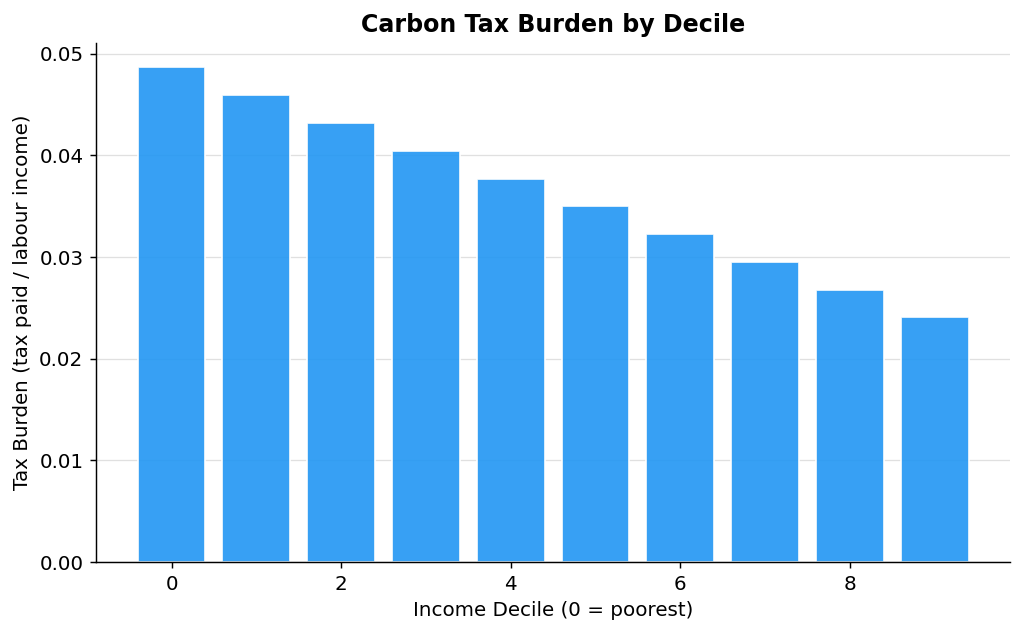

Figure 1 saved.


In [30]:
# Figure 1: Carbon Tax Burden by Decile
# Shows regressivity before any revenue recycling

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(np.arange(10), burden_decile,
       color=COLOR_LUMP, alpha=0.9, edgecolor="white")

ax.set_xlabel("Income Decile (0 = poorest)")
ax.set_ylabel("Tax Burden (tax paid / labour income)")
ax.set_title("Carbon Tax Burden by Decile", fontweight="bold")
ax.yaxis.grid(True, color=COLOR_GRID, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("figures/fig1_carbon_tax_burden.png", bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

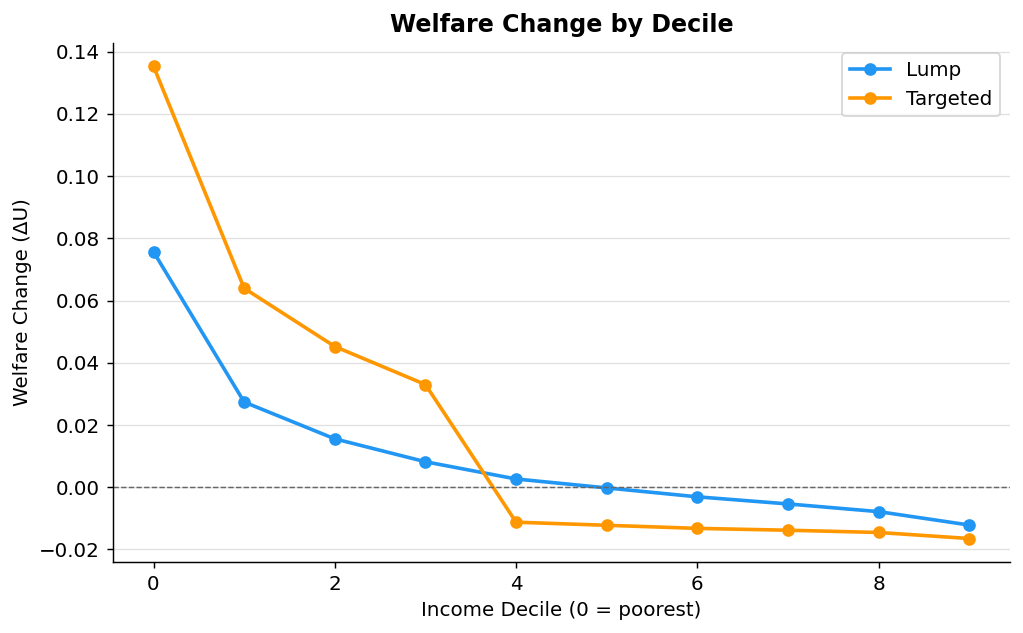

Figure 2 saved.


In [31]:
# Figure 2: Welfare Change by Decile
# ΔU vs no-tax baseline for both recycling schemes on the same plot for direct comparison

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.arange(10), dU_A_decile, color=COLOR_LUMP,
        marker="o", linewidth=2, label="Lump")
ax.plot(np.arange(10), dU_B_decile, color=COLOR_TARGETED,
        marker="o", linewidth=2, label="Targeted")
ax.axhline(0, color="#666666", linewidth=0.8, linestyle="--")

ax.set_xlabel("Income Decile (0 = poorest)")
ax.set_ylabel("Welfare Change (ΔU)")
ax.set_title("Welfare Change by Decile", fontweight="bold")
ax.legend(frameon=True)
ax.yaxis.grid(True, color=COLOR_GRID, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("figures/fig2_welfare_change.png", bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

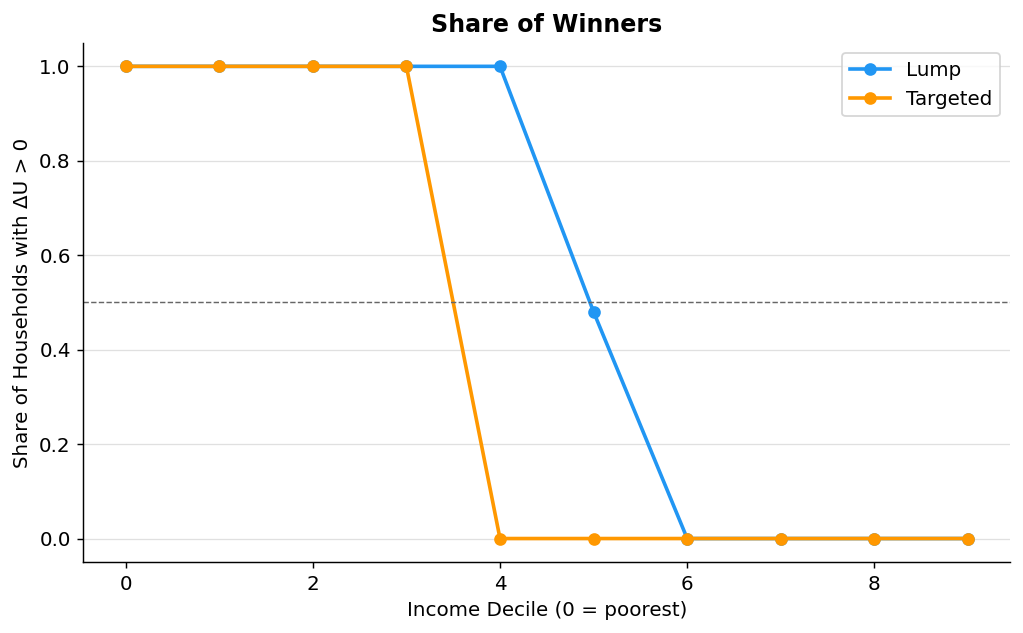

Figure 3 saved.


In [32]:
# Figure 3: Share of Winners
# Fraction of households in each decile with ΔU > 0 for both schemes on the same plot

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.arange(10), winners_A, color=COLOR_LUMP,
        marker="o", linewidth=2, label="Lump")
ax.plot(np.arange(10), winners_B, color=COLOR_TARGETED,
        marker="o", linewidth=2, label="Targeted")
ax.axhline(0.5, color="#666666", linewidth=0.8, linestyle="--")

ax.set_xlabel("Income Decile (0 = poorest)")
ax.set_ylabel("Share of Households with ΔU > 0")
ax.set_title("Share of Winners", fontweight="bold")
ax.legend(frameon=True)
ax.yaxis.grid(True, color=COLOR_GRID, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("figures/fig3_share_of_winners.png", bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

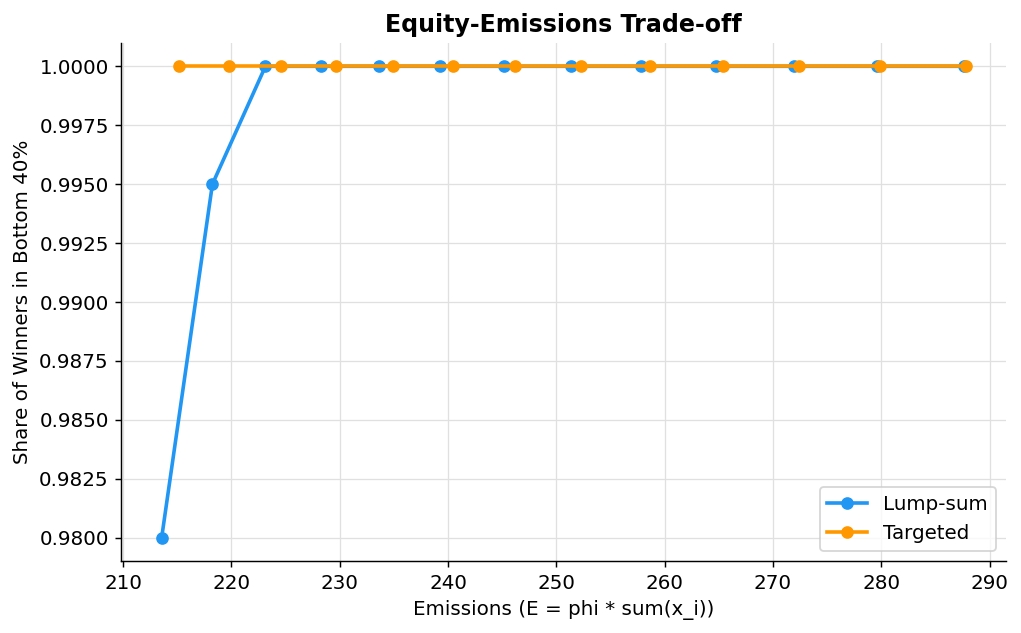

Figure 4 saved.


In [33]:
# Figure 4: Equity-Emissions Trade-off
# For a given emissions level, targeted recycling protects the bottom 40% better
# (PDF Section 7, Chart 4)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(sens_df["E_A"], sens_df["winners_bot40_A"],
        color=COLOR_LUMP, marker="o", linewidth=2, label="Lump-sum")
ax.plot(sens_df["E_B"], sens_df["winners_bot40_B"],
        color=COLOR_TARGETED, marker="o", linewidth=2, label="Targeted")

ax.set_xlabel("Emissions (E = phi * sum(x_i))")
ax.set_ylabel("Share of Winners in Bottom 40%")
ax.set_title("Equity-Emissions Trade-off", fontweight="bold")
ax.legend(frameon=True)
ax.yaxis.grid(True, color=COLOR_GRID, linewidth=0.7)
ax.xaxis.grid(True, color=COLOR_GRID, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("figures/fig4_equity_emissions_tradeoff.png", bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

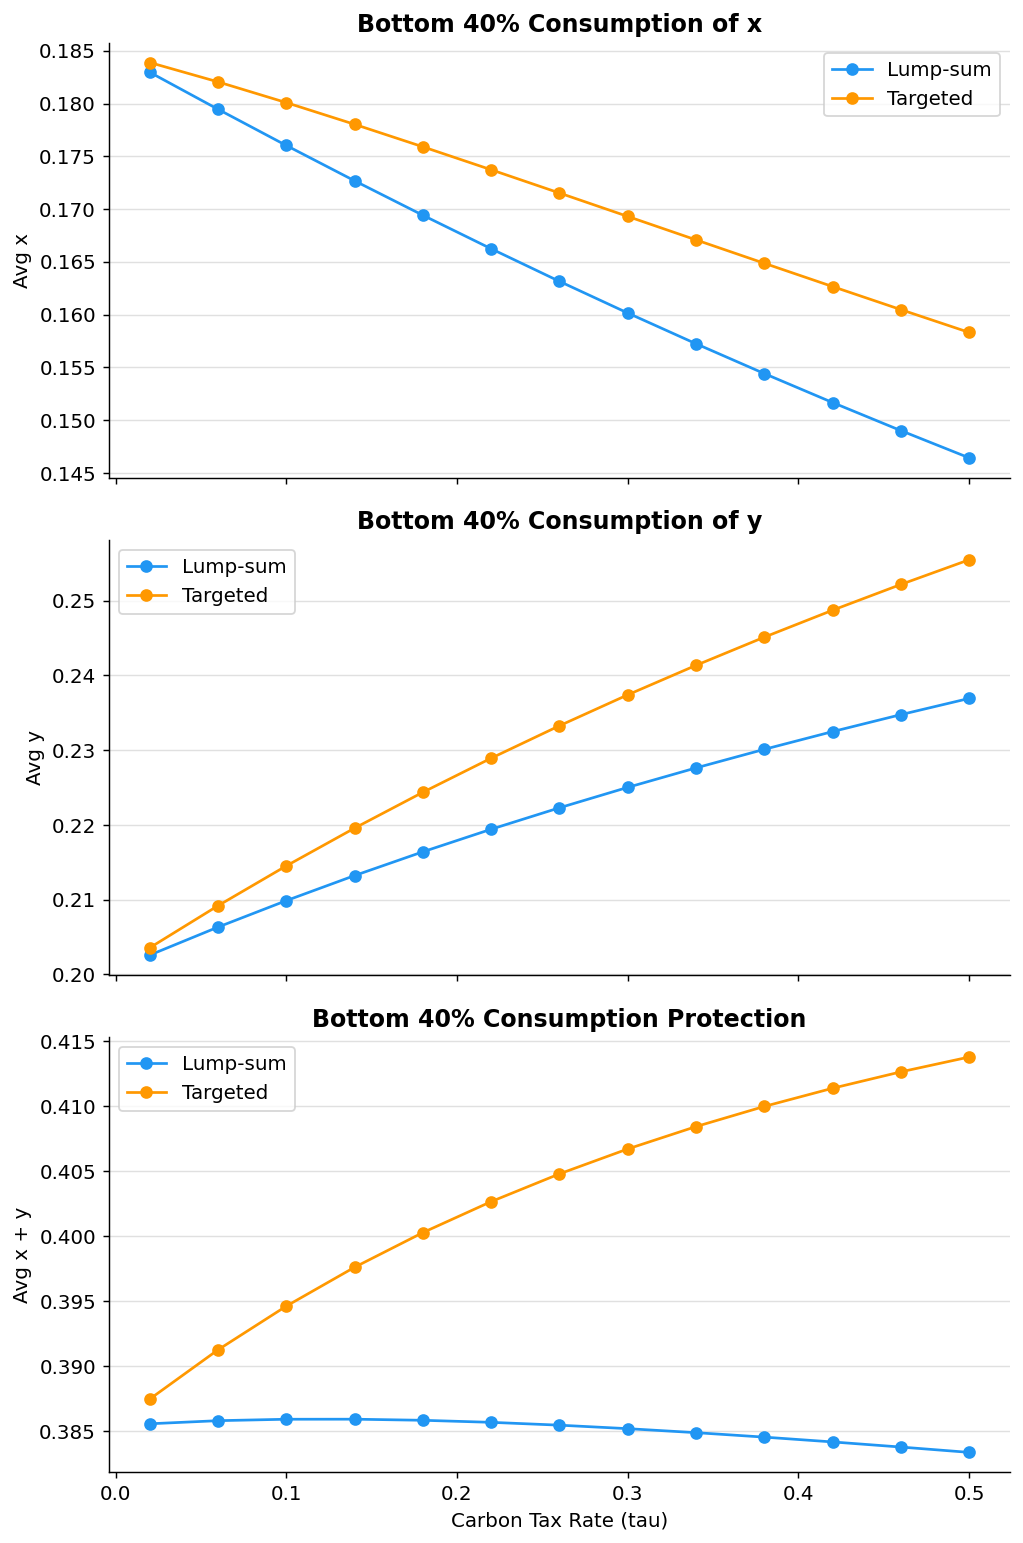

Figure 5 saved.


In [34]:
# Figure 5: Bottom 40% Protection
# Average consumption of x, y, and x+y for bottom 40% as tau varies


fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(sens_df["tau"], sens_df["avg_x_A"],
             color=COLOR_LUMP, marker="o", label="Lump-sum")
axes[0].plot(sens_df["tau"], sens_df["avg_x_B"],
             color=COLOR_TARGETED, marker="o", label="Targeted")
axes[0].set_ylabel("Avg x")
axes[0].set_title("Bottom 40% Consumption of x", fontweight="bold")
axes[0].legend(frameon=True)
axes[0].yaxis.grid(True, color=COLOR_GRID)

axes[1].plot(sens_df["tau"], sens_df["avg_y_A"],
             color=COLOR_LUMP, marker="o", label="Lump-sum")
axes[1].plot(sens_df["tau"], sens_df["avg_y_B"],
             color=COLOR_TARGETED, marker="o", label="Targeted")
axes[1].set_ylabel("Avg y")
axes[1].set_title("Bottom 40% Consumption of y", fontweight="bold")
axes[1].legend(frameon=True)
axes[1].yaxis.grid(True, color=COLOR_GRID)

axes[2].plot(sens_df["tau"], sens_df["avg_xy_A"],
             color=COLOR_LUMP, marker="o", label="Lump-sum")
axes[2].plot(sens_df["tau"], sens_df["avg_xy_B"],
             color=COLOR_TARGETED, marker="o", label="Targeted")
axes[2].set_xlabel("Carbon Tax Rate (tau)")
axes[2].set_ylabel("Avg x + y")
axes[2].set_title("Bottom 40% Consumption Protection", fontweight="bold")
axes[2].legend(frameon=True)
axes[2].yaxis.grid(True, color=COLOR_GRID)

for ax in axes:
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("figures/fig5_bottom40_protection.png", bbox_inches="tight")
plt.show()
print("Figure 5 saved.")

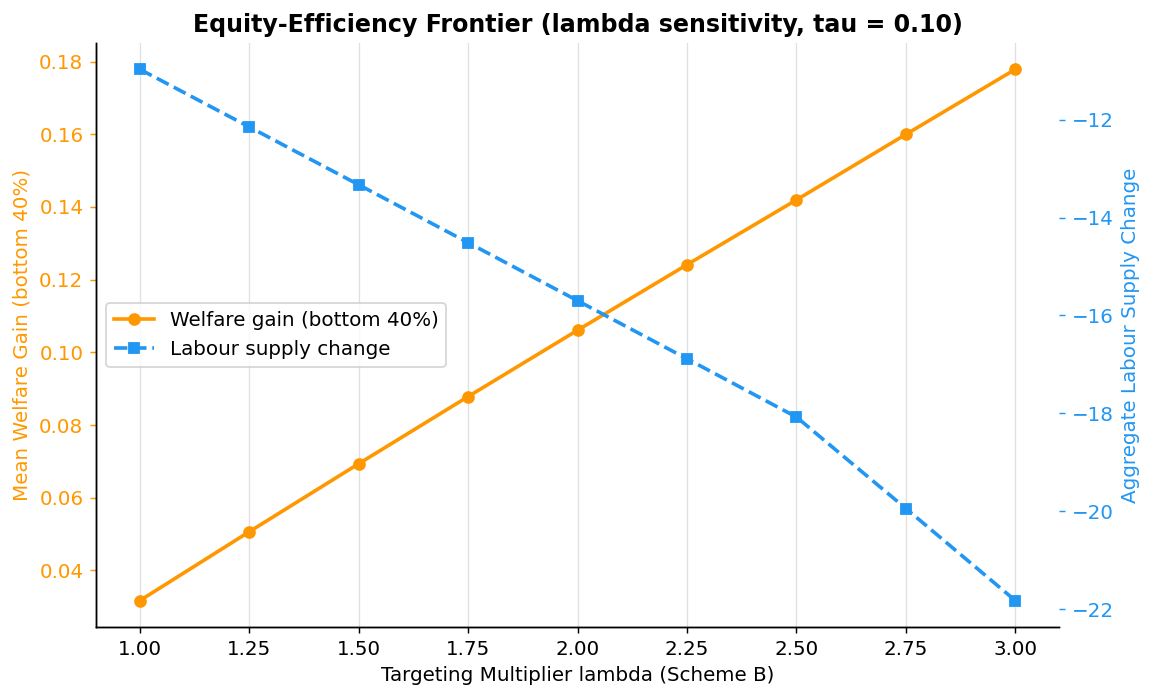

Figure 6 saved.


In [35]:
# Figure 6: Equity-Efficiency Frontier (lambda sensitivity)
# Welfare gain for bottom 40% vs aggregate labour supply cost across targeting strengths

lam_grid   = np.linspace(1.0, 3.0, 9)
lam_results = []

for lam_val in lam_grid:
    l_b, x_b, y_b, _, _, _ = solve_scheme_B(wages, gamma, params,
                                              lam=lam_val, verbose=False)
    U_b  = household_utility(x_b, y_b, l_b, gamma, params["alpha"])
    dU_b = U_b - U_notax
    lam_results.append({
        "lam"          : lam_val,
        "welfare_bot40": dU_b[bot_mask].mean(),
        "labour_loss"  : l_b.sum() - L_notax,
    })

lam_df = pd.DataFrame(lam_results)

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax2 = ax1.twinx()

line1, = ax1.plot(
    lam_df["lam"], lam_df["welfare_bot40"],
    color=COLOR_TARGETED, marker="o", linewidth=2,
    label="Welfare gain (bottom 40%)")

line2, = ax2.plot(
    lam_df["lam"], lam_df["labour_loss"],
    color=COLOR_LUMP, marker="s", linewidth=2, linestyle="--",
    label="Labour supply change")

ax1.set_xlabel("Targeting Multiplier lambda (Scheme B)")
ax1.set_ylabel("Mean Welfare Gain (bottom 40%)", color=COLOR_TARGETED)
ax2.set_ylabel("Aggregate Labour Supply Change",  color=COLOR_LUMP)
ax1.set_title("Equity-Efficiency Frontier (lambda sensitivity, tau = 0.10)",
              fontweight="bold")

ax1.tick_params(axis="y", colors=COLOR_TARGETED)
ax2.tick_params(axis="y", colors=COLOR_LUMP)

ax1.legend(handles=[line1, line2], loc="center left", frameon=True)
ax1.xaxis.grid(True, color=COLOR_GRID, linewidth=0.7)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.savefig("figures/fig6_equity_efficiency_frontier.png", bbox_inches="tight")
plt.show()
print("Figure 6 saved.")

---
## Summary of Results

The cell below prints a concise summary of all key findings.

In [36]:
print("=" * 65)
print("  RESULTS SUMMARY")
print("=" * 65)

print(f"\nParameters: tau={params['tau']}, phi={params['phi']}, alpha={params['alpha']}")
print(f"            gamma_base={params['gamma_base']}, delta={params['delta']},")
print(f"            lambda={params['lam']}, N={params['N']}")

print(f"\nGini of simulated wage distribution : {compute_gini(wages):.4f}")

print(f"\nEquilibrium transfers:")
print(f"  Scheme A — universal rebate T    = {T_A:.6f}")
print(f"  Scheme B — T_low  (bottom 40%)   = {T_B_low:.6f}")
print(f"  Scheme B — T_high (top 60%)      = {T_B_high:.6f}")

print(f"\nNewton check: T = {T_newton:.6f}  (diff = {abs(T_A - T_newton):.2e})")

print(f"\nAggregate labour supply:")
print(f"  No-tax baseline : {L_notax:.4f}")
print(f"  Scheme A        : {L_A:.4f}   ({L_A - L_notax:+.4f} vs baseline)")
print(f"  Scheme B        : {L_B:.4f}   ({L_B - L_notax:+.4f} vs baseline)")

dU_A_bot = dU_A[bot_mask].mean()
dU_B_bot = dU_B[bot_mask].mean()

print(f"\nMean welfare gain — bottom 40%:")
print(f"  Scheme A : {dU_A_bot:.6f}")
print(f"  Scheme B : {dU_B_bot:.6f}")

pct = (dU_B_bot - dU_A_bot) / abs(dU_A_bot) * 100
print(f"\nScheme B improves bottom-40% welfare by {pct:.1f}% more than Scheme A.")
print(f"\nLabour efficiency cost of Scheme B vs A: {L_B - L_A:+.4f}")

print("\n" + "=" * 65)

  RESULTS SUMMARY

Parameters: tau=0.1, phi=1.0, alpha=0.5
            gamma_base=0.55, delta=0.3,
            lambda=1.5, N=1000

Gini of simulated wage distribution : 0.3536

Equilibrium transfers:
  Scheme A — universal rebate T    = 0.027194
  Scheme B — T_low  (bottom 40%)   = 0.040867
  Scheme B — T_high (top 60%)      = 0.018163

Newton check: T = 0.027194  (diff = 9.39e-09)

Aggregate labour supply:
  No-tax baseline : 666.6667
  Scheme A        : 655.6957   (-10.9710 vs baseline)
  Scheme B        : 653.3359   (-13.3307 vs baseline)

Mean welfare gain — bottom 40%:
  Scheme A : 0.031681
  Scheme B : 0.069344

Scheme B improves bottom-40% welfare by 118.9% more than Scheme A.

Labour efficiency cost of Scheme B vs A: -2.3597

